# Score-only pooled refinement after forward addition factor 0.1

This paired experiment starts from the new preferred five-member forward-knee
configuration with `addition_factor=0.1`, `combined_rank(weight=0.75)`, a
20-feature cap, separate feature sets and parameters, and no ensemble holdout.
It then applies score-only ensemble-pooled stochastic refinement at temperature
0.05 for at most 200 iterations with patience 50 and cooling rate 0.97.

In [1]:
from pathlib import Path
import copy
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "mistic" / "svmSet.py").exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mistic import combined_rank, cvSet, kernelWrapper, paramSet, score_svc, svmSet

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

Matplotlib is building the font cache; this may take a moment.


## Fixed experimental design

- 500 observations and 100 predictors: 10 informative, 10 redundant, and 80 noise.
- One stratified 25% blind set, withheld before every preprocessing and modeling step.
- Three inner seeds and exactly five SVM-set members.
- Fifteen percent of the outer-training rows are reserved for ensemble-level validation and excluded from all member CV splits.
- `combined_rank(weight=0.75)`, separate feature sets, and separate parameters.
- Forward search uses the 20-medoid singleton screen and a 20-feature maximum.
- Backward search uses scaled gamma during search and final full-grid retuning.
- Greedy selection returns the knee-selected subset before refinement.
- Stochastic variants start from identical deep copies of that subset. Every iteration budget uses the same seed. Both single-model proposals and joint all-model proposals are tested.
- Each sklearn unified-feature reference uses only the top `knee_feature_count`
  features according to the corresponding ensemble's unified rank.

In [2]:
N_SAMPLES = 500
N_FEATURES = 100
N_INFORMATIVE = 10
N_REDUNDANT = 10
SIGNAL_FEATURES = set(range(N_INFORMATIVE + N_REDUNDANT))

X_values, y_values = make_classification(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    n_informative=N_INFORMATIVE,
    n_redundant=N_REDUNDANT,
    n_repeated=0,
    n_classes=2,
    weights=[0.55, 0.45],
    class_sep=1.0,
    flip_y=0.03,
    shuffle=False,
    random_state=2026,
)
X = pd.DataFrame(X_values)
y = pd.Series(y_values, name="class")

MODEL_COUNTS = [5]
REFINEMENT_STEPS = [0, 10, 20, 50, 100]
SELECTION_STRATEGIES = ["forward_knee", "backward_knee"]
INNER_SEEDS = list(range(3))
BLIND_SET_SEED = 42
TEST_SIZE = 0.25
INNER_VALIDATION_SIZE = 0.20
ENSEMBLE_VALIDATION_SIZE = 0.0
RANK_WEIGHT = 0.75
FORWARD_MAX_FEATURES = 20
C_VALUES = [0.25, 1.0, 4.0]
GAMMA_VALUES = [2.0 ** exponent for exponent in (-9, -7, -5)]

X_train, X_blind, y_train, y_blind = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=BLIND_SET_SEED
)
print(f"Training rows: {len(X_train)}; fixed blind rows: {len(X_blind)}")

Training rows: 375; fixed blind rows: 125


In [3]:
def parameter_grid():
    return [
        paramSet(model={"C": cost}, kernel={"gamma": gamma})
        for cost in C_VALUES for gamma in GAMMA_VALUES
    ]


def metric_row(y_true, predictions, decision_values):
    return {
        "roc_auc": roc_auc_score(y_true, decision_values),
        "f1": f1_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "accuracy": accuracy_score(y_true, predictions),
    }


def fit_sklearn_reference(X_train_subset, y_train, seed):
    pipeline = Pipeline([
        ("scale", StandardScaler()),
        ("svc", SVC(kernel="rbf", class_weight="balanced")),
    ])
    search = GridSearchCV(
        pipeline,
        {"svc__C": C_VALUES, "svc__gamma": GAMMA_VALUES},
        scoring="roc_auc",
        cv=StratifiedKFold(n_splits=4, shuffle=True, random_state=seed),
        n_jobs=-1,
        refit=True,
    )
    return search.fit(X_train_subset, y_train)


def fit_knee_ensemble(strategy, num_models, seed):
    scaler = StandardScaler().fit(X_train)
    X_scaled = scaler.transform(X_train)
    splits = cvSet(
        X_scaled,
        np.asarray(y_train),
        num_feature_medoids=20,
        ensemble_validation_size=ENSEMBLE_VALIDATION_SIZE,
        ensemble_validation_random_seed=50_000,
        ensemble_validation_stratify=True,
    )
    splits.classification(
        num_sets=num_models,
        validation_size=INNER_VALIDATION_SIZE,
        random_seed=seed,
    )
    ensemble = svmSet(
        SVC(kernel="precomputed", class_weight="balanced"),
        splits,
        score_method=score_svc(weight=1.0).score,
        kernel=kernelWrapper(type="rbf"),
        separate_feature_sets=True,
        separate_parameters=True,
    )
    options = dict(
        parameter_grid=parameter_grid(),
        feature_ranker=combined_rank(weight=RANK_WEIGHT).compute,
        set_for_rank="sample",
        tune_models_each_step=False,
        post_find_knee=True,
    )
    if strategy == "forward_knee":
        ensemble.greedy_forward_selection(
            addition_factor=0.1,
            max_features=FORWARD_MAX_FEATURES,
            **options,
        )
    else:
        ensemble.greedy_backward_selection(reduction_factor=0.1, **options)
    return scaler, ensemble, ensemble.find_knee(metric="score")


def ranked_unified_features(ensemble, limit):
    unified_set = set(np.asarray(ensemble.unified_features, dtype=int))
    ranked = np.asarray([
        feature for feature in ensemble.unified_sorted_features
        if feature in unified_set
    ], dtype=int)
    return ranked[:min(int(limit), len(ranked))]


def recovery(features):
    features = np.asarray(features, dtype=int)
    signal_count = len(set(features).intersection(SIGNAL_FEATURES))
    return signal_count / len(SIGNAL_FEATURES), 1 - signal_count / len(features)


def ensemble_row(ensemble, scaler, seed, strategy, num_models, steps, knee_count, update_all_models):
    X_blind_scaled = scaler.transform(X_blind)
    predictions = ensemble.predict(X_blind_scaled)
    decisions = ensemble.decision_function(X_blind_scaled)
    unified = np.asarray(ensemble.unified_features, dtype=int)
    top20 = ranked_unified_features(ensemble, 20)
    signal_recall, noise_fraction = recovery(top20)
    member_predictions = np.column_stack([
        ensemble.predict(X_blind_scaled, model_index=i) for i in range(num_models)
    ])
    disagreement = np.mean([
        np.mean(member_predictions[:, i] != member_predictions[:, j])
        for i in range(num_models) for j in range(i + 1, num_models)
    ]) if num_models > 1 else 0.0
    history = getattr(ensemble, "stochastic_performance_", [])
    return {
        "seed": seed,
        "method": "MiSTIC SVM set",
        "selection_strategy": strategy,
        "refinement_steps": steps,
        "update_all_models": update_all_models,
        "refinement_objective": "ensemble_validation" if steps else "knee_baseline",
        "num_models": num_models,
        "knee_feature_count": knee_count,
        "num_unified_features": len(unified),
        "signal_recall": signal_recall,
        "noise_fraction": noise_fraction,
        "member_disagreement": disagreement,
        "accepted_moves": sum(row.accepted for row in history),
        **metric_row(y_blind, predictions, decisions),
    }


def reference_row(ensemble, seed, strategy, num_models, steps, knee_count, update_all_models):
    features = ranked_unified_features(ensemble, knee_count)
    signal_recall, noise_fraction = recovery(features)
    reference = fit_sklearn_reference(X_train.iloc[:, features], y_train, seed)
    return {
        "seed": seed,
        "method": "sklearn on knee-ranked unified features",
        "selection_strategy": strategy,
        "refinement_steps": steps,
        "update_all_models": update_all_models,
        "refinement_objective": "ensemble_validation" if steps else "knee_baseline",
        "num_models": num_models,
        "knee_feature_count": knee_count,
        "num_unified_features": len(features),
        "signal_recall": signal_recall,
        "noise_fraction": noise_fraction,
        "member_disagreement": 0.0,
        "accepted_moves": np.nan,
        **metric_row(
            y_blind,
            reference.predict(X_blind.iloc[:, features]),
            reference.decision_function(X_blind.iloc[:, features]),
        ),
    }

## Run the comparison

For each seed and selection direction, the two refined conditions begin from
independent copies of the same knee-selected ensemble. Refinement retunes every
proposal with the same parameter grid used by the greedy search.

In [4]:
rows = []
history_rows = []
strategy = "forward_knee"
num_models = 5
max_steps = 200
for seed in INNER_SEEDS:
    scaler, base_ensemble, knee_count = fit_knee_ensemble(
        strategy, num_models, seed
    )
    rows.append(ensemble_row(
        base_ensemble, scaler, seed, strategy, num_models, 0, knee_count, False,
    ))
    rows[-1].update({
        "method": "Forward addition 0.1 baseline",
        "selection_strategy": "forward_knee_no_holdout",
        "search_max_steps": 0,
        "iterations_run": 0,
        "converged": False,
        "stop_reason": "not_run",
        "search_best_score": np.nan,
    })

    candidate = copy.deepcopy(base_ensemble)
    candidate.ensemble_stochastic_feature_selection(
        parameter_grid(),
        n_iterations=max_steps,
        temperature=0.05,
        cooling_rate=0.97,
        add_probability=0.5,
        random_seed=10_000 + 100 * num_models + seed,
        convergence_patience=50,
    )
    rows.append(ensemble_row(
        candidate, scaler, seed, strategy, num_models,
        candidate.ensemble_stochastic_iterations_, knee_count, False,
    ))
    rows[-1].update({
        "method": "Forward addition 0.1 plus pooled refinement",
        "selection_strategy": "forward_addition01_ensemble_pooled_no_holdout",
        "search_max_steps": max_steps,
        "iterations_run": candidate.ensemble_stochastic_iterations_,
        "converged": candidate.ensemble_stochastic_converged_,
        "stop_reason": candidate.ensemble_stochastic_stop_reason_,
        "search_best_score": candidate.ensemble_stochastic_best_score_,
        "accepted_moves": sum(
            record.accepted
            for record in candidate.ensemble_stochastic_performance_
        ),
    })
    rows.append(reference_row(
        candidate, seed, strategy, num_models,
        candidate.ensemble_stochastic_iterations_, knee_count, False,
    ))
    rows[-1].update({
        "method": "sklearn on forward-0.1 pooled unified features",
        "selection_strategy": "forward_addition01_ensemble_pooled_no_holdout",
        "search_max_steps": max_steps,
        "iterations_run": candidate.ensemble_stochastic_iterations_,
        "converged": candidate.ensemble_stochastic_converged_,
        "stop_reason": candidate.ensemble_stochastic_stop_reason_,
        "search_best_score": candidate.ensemble_stochastic_best_score_,
    })

    running_best = -np.inf
    for record in candidate.ensemble_stochastic_performance_:
        if record.accepted:
            running_best = max(running_best, record.score)
        history_rows.append({
            "seed": seed,
            "step": record.iteration + 1,
            "estimated_score": record.estimated_score,
            "actual_score": record.score,
            "accepted": record.accepted,
            "best_accepted_proposal_score": (
                running_best if np.isfinite(running_best) else np.nan
            ),
            "pool_size": record.pool_size,
            "temperature": record.temperature,
        })
    print(
        f"completed seed={seed}; "
        f"iterations={candidate.ensemble_stochastic_iterations_}; "
        f"stop={candidate.ensemble_stochastic_stop_reason_}"
    )

no_holdout_results = pd.DataFrame(rows)
no_holdout_history = pd.DataFrame(history_rows)
no_holdout_results.to_csv(
    repo_root / "validation/Synthetic100_forward_addition01_pooled_refinement200_results.csv",
    index=False,
)
no_holdout_history.to_csv(
    repo_root / "validation/Synthetic100_forward_addition01_pooled_refinement200_history.csv",
    index=False,
)
no_holdout_results

Number of Features: 1, Score: 0.698


Number of Features: 10, Score: 0.791


Number of Features: 19, Score: 0.786


Number of Features: 20, Score: 0.786
Number of Features: 100, Score: 0.768


completed seed=0; iterations=108; stop=converged


...

Number of Features: 10, Score: 0.747


Number of Features: 19, Score: 0.745


Number of Features: 20, Score: 0.742
Number of Features: 100, Score: 0.703


completed seed=2; iterations=50; stop=converged


,seed,method,selection_strategy,refinement_steps,update_all_models,refinement_objective,num_models,knee_feature_count,num_unified_features,signal_recall,...,accepted_moves,roc_auc,f1,balanced_accuracy,accuracy,search_max_steps,iterations_run,converged,stop_reason,search_best_score
0,0,Forward addition 0.1 baseline,forward_knee_no_holdout,0,False,knee_baseline,5,10,23,0.60,...,0.0,0.959110,0.867257,0.879529,0.880,0,0,False,not_run,NaN
1,0,Forward addition 0.1 plus pooled refinement,forward_addition01_ensemble_pooled_no_holdout,108,False,ensemble_validation,5,10,31,0.65,...,87.0,0.955487,0.884956,0.895704,0.896,200,108,True,converged,0.919388
2,0,sklearn on forward-0.1 pooled unified features,forward_addition01_ensemble_pooled_no_holdout,108,False,ensemble_validation,5,10,10,0.45,...,NaN,0.966874,0.896552,0.906315,0.904,200,108,True,converged,0.919388
3,1,Forward addition 0.1 baseline,forward_knee_no_holdout,0,False,knee_baseline,5,20,39,0.65,...,0.0,0.956522,0.881356,0.891822,0.888,0,0,False,not_run,NaN
4,1,Forward addition 0.1 plus pooled refinement,forward_addition01_ensemble_pooled_no_holdout,58,False,ensemble_validation,5,20,42,0.65,...,57.0,0.959110,0.877193,0.888458,0.888,200,58,True,converged,0.928176
5,1,sklearn on forward-0.1 pooled unified features,forward_addition01_ensemble_pooled_no_holdout,58,False,ensemble_validation,5,20,20,0.65,...,NaN,0.940994,0.857143,0.870600,0.872,200,58,True,converged,0.928176
6,2,Forward addition 0.1 baseline,forward_knee_no_holdout,0,False,knee_baseline,5,10,25,0.65,...,0.0,0.962733,0.892857,0.902950,0.904,0,0,False,not_run,NaN
7,2,Forward addition 0.1 plus pooled refinement,forward_addition01_ensemble_pooled_no_holdout,50,False,ensemble_validation,5,10,25,0.65,...,48.0,0.962733,0.892857,0.902950,0.904,200,50,True,converged,0.871507
8,2,sklearn on forward-0.1 pooled unified features,forward_addition01_ensemble_pooled_no_holdout,50,False,ensemble_validation,5,10,10,0.40,...,NaN,0.965062,0.907563,0.916925,0.912,200,50,True,converged,0.871507


## Blind-set comparison

The score-only refinement is compared directly with its paired forward
addition-factor-0.1 initialization and with the earlier forward factor-0
score-only refinement.

In [5]:
old_score_only = pd.read_csv(
    repo_root / "validation/Synthetic100_svmSet_forward_ensemble_pooled_search_no_holdout_results.csv"
).query("method == 'No-holdout ensemble-pooled search'").copy()
old_score_only["method"] = "Forward factor 0 plus pooled refinement"

comparison = pd.concat(
    [no_holdout_results, old_score_only], ignore_index=True
)
comparison.groupby("method").agg(
    mean_auc=("roc_auc", "mean"),
    sd_auc=("roc_auc", "std"),
    mean_f1=("f1", "mean"),
    mean_accuracy=("accuracy", "mean"),
    mean_signal_recall=("signal_recall", "mean"),
    mean_signal_precision=("noise_fraction", lambda x: 1 - x.mean()),
    mean_disagreement=("member_disagreement", "mean"),
    mean_union_size=("num_unified_features", "mean"),
    mean_iterations=("iterations_run", "mean"),
    mean_accepted=("accepted_moves", "mean"),
).round(4)

,mean_auc,sd_auc,mean_f1,mean_accuracy,mean_signal_recall,mean_signal_precision,mean_disagreement,mean_union_size,mean_iterations,mean_accepted
method,,,,,,,,,,
Forward addition 0.1 baseline,0.9595,0.0031,0.8805,0.8907,0.6333,0.6333,0.1744,29.0000,0.0000,0.0000
Forward addition 0.1 plus pooled refinement,0.9591,0.0036,0.8850,0.8960,0.6500,0.6500,0.1707,32.6667,72.0000,64.0000
Forward factor 0 plus pooled refinement,0.9521,0.0124,0.8630,0.8720,0.5667,0.5667,0.2107,29.0000,68.6667,62.3333
sklearn on forward-0.1 pooled unified features,0.9576,0.0144,0.8871,0.8960,0.5000,0.7833,0.0000,13.3333,72.0000,NaN


In [6]:
base = no_holdout_results.query(
    "method == 'Forward addition 0.1 baseline'"
).set_index("seed")
refined = no_holdout_results.query(
    "method == 'Forward addition 0.1 plus pooled refinement'"
).set_index("seed")
paired = pd.DataFrame({
    "delta_auc_refined_minus_baseline": refined["roc_auc"] - base["roc_auc"],
    "delta_f1_refined_minus_baseline": refined["f1"] - base["f1"],
    "delta_accuracy_refined_minus_baseline": refined["accuracy"] - base["accuracy"],
    "delta_recall_refined_minus_baseline": refined["signal_recall"] - base["signal_recall"],
    "delta_union_refined_minus_baseline": refined["num_unified_features"] - base["num_unified_features"],
    "iterations_run": refined["iterations_run"],
    "stop_reason": refined["stop_reason"],
})
pd.concat([
    paired,
    pd.DataFrame([paired.select_dtypes("number").mean().rename("mean")]),
])

,delta_auc_refined_minus_baseline,delta_f1_refined_minus_baseline,delta_accuracy_refined_minus_baseline,delta_recall_refined_minus_baseline,delta_union_refined_minus_baseline,iterations_run,stop_reason
0,-0.003623,0.017699,0.016000,0.050000,8.000000,108.0,converged
1,0.002588,-0.004163,0.000000,0.000000,3.000000,58.0,converged
2,0.000000,0.000000,0.000000,0.000000,0.000000,50.0,converged
mean,-0.000345,0.004512,0.005333,0.016667,3.666667,72.0,NaN


## Search-objective trajectory

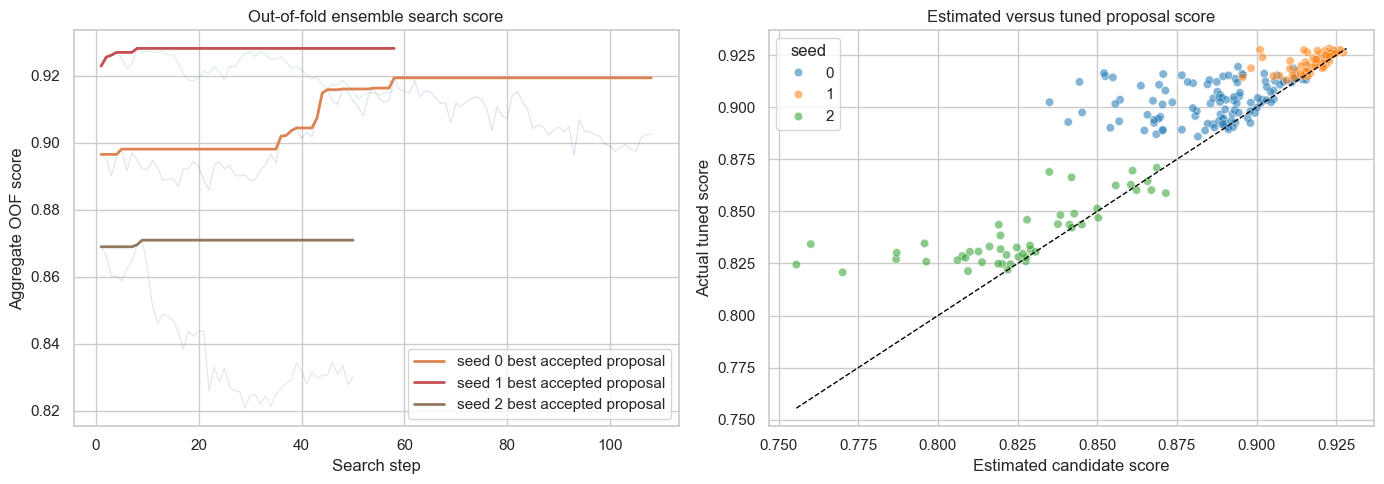

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for seed in INNER_SEEDS:
    values = no_holdout_history.query("seed == @seed")
    axes[0].plot(values["step"], values["actual_score"], alpha=0.2, linewidth=0.8)
    axes[0].plot(values["step"], values["best_accepted_proposal_score"], linewidth=2, label=f"seed {seed} best accepted proposal")
axes[0].set(
    title="Out-of-fold ensemble search score",
    xlabel="Search step", ylabel="Aggregate OOF score",
)
axes[0].legend()

sns.scatterplot(
    data=no_holdout_history, x="estimated_score", y="actual_score",
    hue="seed", alpha=0.55, ax=axes[1], palette="tab10",
)
limits = [
    min(no_holdout_history["estimated_score"].min(), no_holdout_history["actual_score"].min()),
    max(no_holdout_history["estimated_score"].max(), no_holdout_history["actual_score"].max()),
]
axes[1].plot(limits, limits, color="black", linestyle="--", linewidth=1)
axes[1].set(
    title="Estimated versus tuned proposal score",
    xlabel="Estimated candidate score", ylabel="Actual tuned score",
)
plt.tight_layout()